In [163]:
%pip install flwr
%pip install scikit-learn
%pip install seaborn
%pip install nltk
%pip install nest_asyncio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import flwr as fl
import threading

def start_server():
    def weighted_average(metrics):
        total_examples = sum(num_examples for num_examples, _ in metrics)
        total_accuracy = sum(num_examples * m["accuracy"] for num_examples, m in metrics) / total_examples
        return {"accuracy": total_accuracy}

    # Define the strategy with your custom aggregation function
    strategy = fl.server.strategy.FedAvg(
        evaluate_metrics_aggregation_fn=weighted_average
    )
    # config = fl.server.config.FLServerConfig(num_rounds=5)
    # Start the Flower server
    fl.server.start_server(strategy=strategy)
    # fl.server.start_server(config=config, strategy=strategy)

# Start the server in a background thread
server_thread = threading.Thread(target=start_server)
server_thread.start()

INFO :      Starting Flower server, config: num_rounds=1, no round_timeout
INFO :      Flower ECE: gRPC server running (1 rounds), SSL is disabled
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client


In [166]:
import flwr as fl
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import asyncio
import nest_asyncio

# Apply nest_asyncio
nest_asyncio.apply()

class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

def client_fn(cid: str):
    data_path = f"C:/Users/Admin/Desktop/fwdproject/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log_loss', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

async def start_client(client_id):
    client = client_fn(client_id)
    await fl.client.start_client(server_address="localhost:8081", client=client.to_client())

async def main():
    tasks = [start_client(str(cid)) for cid in range(4)]
    await asyncio.gather(*tasks)

# Run the event loop using asyncio.get_event_loop()
if __name__ == "__main__":
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main())

_MultiThreadedRendezvous: <_MultiThreadedRendezvous of RPC that terminated with:
	status = StatusCode.UNAVAILABLE
	details = "failed to connect to all addresses; last error: UNAVAILABLE: ipv4:127.0.0.1:8081: Connection refused"
	debug_error_string = "UNKNOWN:Error received from peer  {grpc_message:"failed to connect to all addresses; last error: UNAVAILABLE: ipv4:127.0.0.1:8081: Connection refused", grpc_status:14, created_time:"2024-07-01T20:18:43.1824333+00:00"}"
>

In [29]:
import pandas as pd



df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/spam_ham_dataset.csv', encoding='utf-8')
# df = pd.read_csv('/content/spam_ham_dataset.csv', encoding='utf-8')


# Load the dataset
df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/spam_ham_dataset.csv')

# Function to split the dataset into 4 parts
def divide_csv(file_path):
    df = pd.read_csv(file_path)
    total_rows = len(df)
    rows_per_part = total_rows // 4
    parts = []
    for i in range(4):
        start_index = i * rows_per_part
        end_index = start_index + rows_per_part if i < 3 else total_rows
        part_df = df.iloc[start_index:end_index]
        parts.append(part_df)
    return parts

# Split the dataset and save to separate files
parts = divide_csv('C:/Users/Admin/Desktop/fwdproject/content/spam_ham_dataset.csv')
for i, part in enumerate(parts):
    part.to_csv(f"C:/Users/Admin/Desktop/fwdproject/content/part_{i+1}.csv", index=False)


In [32]:
# Import Libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix
from sklearn.metrics import classification_report

In [34]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

In [35]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_1.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [22]:
# Exploring the Dataset


# Drop unnecessary columns from the DataFrame
#column_to_remove = ['Unnamed: 2','Unnamed: 3','Unnamed: 4']
#df = df.drop(column_to_remove, axis=1)

In [36]:
df.shape

(1292, 4)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1292 entries, 0 to 1291
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1292 non-null   int64 
 1   label       1292 non-null   object
 2   text        1292 non-null   object
 3   label_num   1292 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 40.5+ KB


In [38]:
df.describe()

,Unnamed: 0,label_num
count,1292.000000,1292.000000
mean,2561.602941,0.287152
std,1470.906843,0.452608
min,0.000000,0.000000
25%,1320.500000,0.000000
50%,2551.500000,0.000000
75%,3825.000000,1.000000
max,5162.000000,1.000000


In [39]:
df[df.duplicated()]

,Unnamed: 0,label,text,label_num


In [40]:
df = df.drop_duplicates()
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
1287,1411,ham,Subject: new storage flag\r\nat your earliest ...,0
1288,2618,ham,Subject: equistar 3 / 01\r\ndaren - here are t...,0
1289,2705,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
1290,2838,ham,Subject: re : noms / actual flow for 3 / 22 / ...,0


In [41]:
df["label"].value_counts()

label
ham     921
spam    371
Name: count, dtype: int64

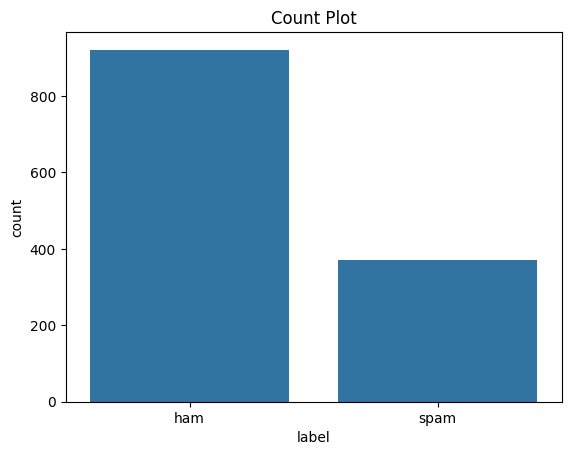

In [42]:
# Data Visualisation


sns.countplot(data=df, x='label')
plt.xlabel('label')
plt.ylabel('count')
plt.title('Count Plot')
plt.show()

In [43]:
# Data Preprocessing
# Convert the "Category" column values to numerical representation (0 for "spam" and 1 for "ham")

df.loc[df["label"] == "ham", "label"] = 0
df.loc[df["label"] == "spam", "label"] = 1

df.head()

,Unnamed: 0,label,text,label_num
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0


In [44]:
# Separate the feature (v2) and target (category) data
X=df['text']
y=df['label']

In [45]:
X

0       Subject: enron methanol ; meter # : 988291\r\n...
1       Subject: hpl nom for january 9 , 2001\r\n( see...
2       Subject: neon retreat\r\nho ho ho , we ' re ar...
3       Subject: photoshop , windows , office . cheap ...
4       Subject: re : indian springs\r\nthis deal is t...
                              ...                        
1287    Subject: new storage flag\r\nat your earliest ...
1288    Subject: equistar 3 / 01\r\ndaren - here are t...
1289    Subject: calpine daily gas nomination\r\n>\r\n...
1290    Subject: re : noms / actual flow for 3 / 22 / ...
1291    Subject: natural gas nomination for 04 / 01\r\...
Name: text, Length: 1292, dtype: object

In [46]:
y

0       0
1       0
2       0
3       1
4       0
       ..
1287    0
1288    0
1289    0
1290    0
1291    0
Name: label, Length: 1292, dtype: object

In [47]:
# Split Data to Train and Test Data


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [48]:
# Feature Extraction - TF-IDF
#Create a TF-IDF vectorizer to convert text messages into numerical feature
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english',lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [49]:
# Model Training
model = LogisticRegression()
model.fit(X_train_features,y_train)

LogisticRegression()

In [50]:

# Model evaluation
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

# Print accuracy
print('Accuracy on training data: {} %'.format(accuracy_on_training_data * 100))
print('Accuracy on test data: {} %'.format(accuracy_on_test_data * 100))

Accuracy on training data: 99.61277831558567 %
Accuracy on test data: 94.98069498069498 %


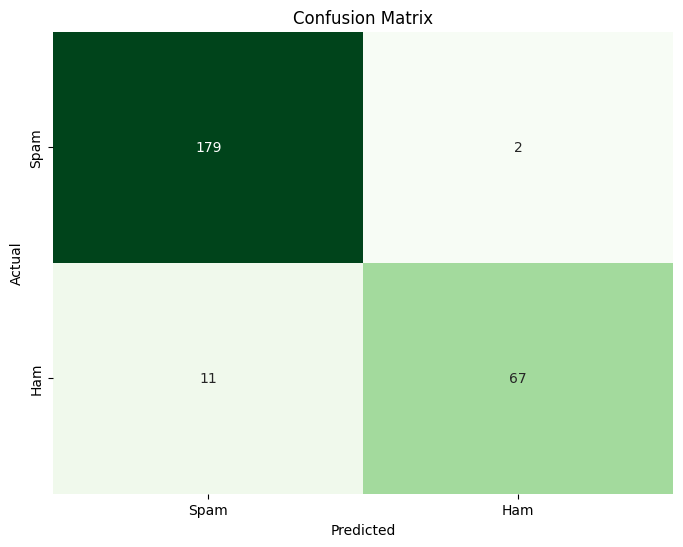

In [51]:
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, prediction_on_test_data)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [52]:
# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

        Spam       0.94      0.99      0.96       181
         Ham       0.97      0.86      0.91        78

    accuracy                           0.95       259
   macro avg       0.96      0.92      0.94       259
weighted avg       0.95      0.95      0.95       259



In [53]:
# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Accuracy : ",accuracy)
print("Precision : ",precision)
print("Recall : ",recall)
print("Specificity : ",specificity)

Accuracy :  0.9498069498069498
Precision :  0.9710144927536232
Recall :  0.8589743589743589
Specificity :  0.988950276243094


In [54]:
# Make Predictions on New Input

input_your_mail ="Dear John, I hope this email finds you well. Attached is the report you requested for our upcoming meeting. Please review it at your convenience"
input_data_features = feature_extraction.transform([input_your_mail])
prediction = model.predict(input_data_features)
if prediction[0] == 1:
    print("Ham Mail")
else:
    print("Spam Mail")

Spam Mail


In [55]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_1.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

# Exploring the Dataset

...

# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

# Weighted counts
total_spam = y_test.value_counts()[1]  # Total spam emails
total_ham = y_test.value_counts()[0]   # Total ham emails

# Weighted average calculation
weighted_accuracy = (TP + TN) / (total_spam + total_ham)
weighted_precision = (precision * total_spam + TN / (TN + FP) * total_ham) / (total_spam + total_ham)
weighted_recall = (recall * total_spam + TN / (TN + FN) * total_ham) / (total_spam + total_ham)
weighted_specificity = (specificity * total_ham + TP / (TP + FN) * total_spam) / (total_spam + total_ham)

print("Weighted Accuracy : ", weighted_accuracy)
print("Weighted Precision : ", weighted_precision)
print("Weighted Recall : ", weighted_recall)
print("Weighted Specificity : ", weighted_specificity)

# Make Predictions on New Input

...


Classification Report:
              precision    recall  f1-score   support

        Spam       0.94      0.99      0.96       181
         Ham       0.97      0.86      0.91        78

    accuracy                           0.95       259
   macro avg       0.96      0.92      0.94       259
weighted avg       0.95      0.95      0.95       259

Weighted Accuracy :  0.9498069498069498
Weighted Precision :  0.9835487661574619
Weighted Recall :  0.9170697012802276
Weighted Specificity :  0.9498069498069498


Ellipsis

In [56]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_2.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

,Unnamed: 0,label,text,label_num
0,3325,ham,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0
1,4622,spam,Subject: want your music for free ? we teach y...,1
2,2686,ham,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0
3,254,ham,Subject: buyer vs . seller on intercompany dea...,0
4,3825,spam,Subject: : : : : : : : : : : : like ma - a - s...,1


In [113]:
# Exploring the Dataset


# Drop unnecessary columns from the DataFrame
#column_to_remove = ['Unnamed: 2','Unnamed: 3','Unnamed: 4']
#df = df.drop(column_to_remove, axis=1)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [57]:
df

,Unnamed: 0,label,text,label_num
0,3325,ham,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0
1,4622,spam,Subject: want your music for free ? we teach y...,1
2,2686,ham,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0
3,254,ham,Subject: buyer vs . seller on intercompany dea...,0
4,3825,spam,Subject: : : : : : : : : : : : like ma - a - s...,1
...,...,...,...,...
1287,1425,ham,"Subject: hpl nom for august 22 , 2000\r\n( see...",0
1288,2009,ham,Subject: re : driscoll ranch # 3 gas pricing a...,0
1289,4169,spam,Subject: from : duve khumalo .\r\nfrom : duve ...,1
1290,473,ham,Subject: cilco storage\r\nthe cilco volumes ar...,0


In [58]:
df.shape

(1292, 4)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1292 entries, 0 to 1291
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1292 non-null   int64 
 1   label       1292 non-null   object
 2   text        1292 non-null   object
 3   label_num   1292 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 40.5+ KB


In [60]:
df.describe()

,Unnamed: 0,label_num
count,1292.000000,1292.000000
mean,2501.003870,0.267028
std,1488.002819,0.442578
min,1.000000,0.000000
25%,1170.250000,0.000000
50%,2495.500000,0.000000
75%,3781.250000,1.000000
max,5166.000000,1.000000


In [61]:
df[df.duplicated()]

,Unnamed: 0,label,text,label_num


In [62]:
df = df.drop_duplicates()
df

,Unnamed: 0,label,text,label_num
0,3325,ham,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0
1,4622,spam,Subject: want your music for free ? we teach y...,1
2,2686,ham,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0
3,254,ham,Subject: buyer vs . seller on intercompany dea...,0
4,3825,spam,Subject: : : : : : : : : : : : like ma - a - s...,1
...,...,...,...,...
1287,1425,ham,"Subject: hpl nom for august 22 , 2000\r\n( see...",0
1288,2009,ham,Subject: re : driscoll ranch # 3 gas pricing a...,0
1289,4169,spam,Subject: from : duve khumalo .\r\nfrom : duve ...,1
1290,473,ham,Subject: cilco storage\r\nthe cilco volumes ar...,0


In [63]:
df["label"].value_counts()

label
ham     947
spam    345
Name: count, dtype: int64

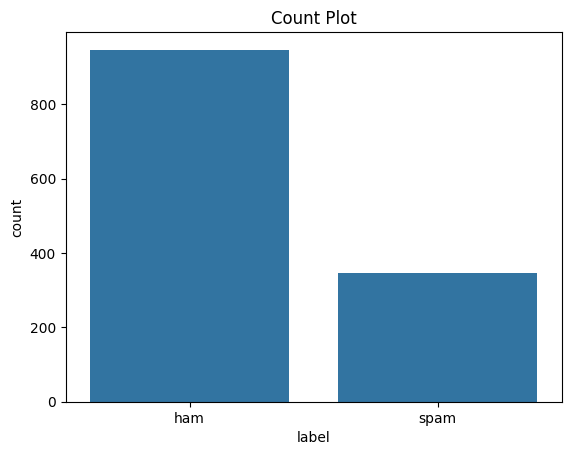

In [64]:
# Data Visualisation


sns.countplot(data=df, x='label')
plt.xlabel('label')
plt.ylabel('count')
plt.title('Count Plot')
plt.show()

In [65]:
# Data Preprocessing
# Convert the "Category" column values to numerical representation (0 for "spam" and 1 for "ham")

df.loc[df["label"] == "ham", "label"] = 0
df.loc[df["label"] == "spam", "label"] = 1

df.head()

,Unnamed: 0,label,text,label_num
0,3325,0,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0
1,4622,1,Subject: want your music for free ? we teach y...,1
2,2686,0,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0
3,254,0,Subject: buyer vs . seller on intercompany dea...,0
4,3825,1,Subject: : : : : : : : : : : : like ma - a - s...,1


In [66]:
# Separate the feature (v2) and target (category) data
X=df['text']
y=df['label']

In [124]:
X

0       Subject: fw : 05 / 01 ena gas sales on hpl , t...
1       Subject: want your music for free ? we teach y...
2       Subject: hpl nom for march 10 - 12 , 2001\r\n(...
3       Subject: buyer vs . seller on intercompany dea...
4       Subject: : : : : : : : : : : : like ma - a - s...
                              ...                        
1287    Subject: hpl nom for august 22 , 2000\r\n( see...
1288    Subject: re : driscoll ranch # 3 gas pricing a...
1289    Subject: from : duve khumalo .\r\nfrom : duve ...
1290    Subject: cilco storage\r\nthe cilco volumes ar...
1291                   Subject: she ' ll enjoy this .\r\n
Name: text, Length: 1292, dtype: object

In [67]:
y

0       0
1       1
2       0
3       0
4       1
       ..
1287    0
1288    0
1289    1
1290    0
1291    1
Name: label, Length: 1292, dtype: object

In [68]:
# Split Data to Train and Test Data


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [69]:
# Feature Extraction - TF-IDF
#Create a TF-IDF vectorizer to convert text messages into numerical feature
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english',lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [70]:
# Model Training
model = LogisticRegression()
model.fit(X_train_features,y_train)

LogisticRegression()

In [71]:

# Model evaluation
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

# Print accuracy
print('Accuracy on training data: {} %'.format(accuracy_on_training_data * 100))
print('Accuracy on test data: {} %'.format(accuracy_on_test_data * 100))

Accuracy on training data: 99.70958373668925 %
Accuracy on test data: 93.43629343629344 %


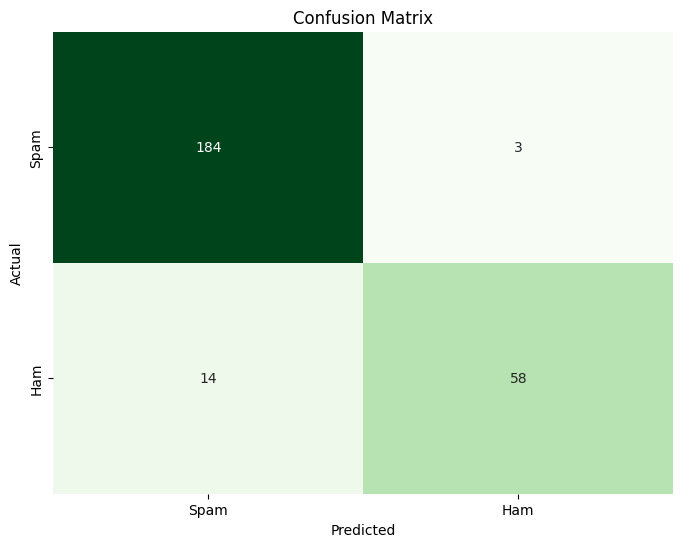

In [72]:
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, prediction_on_test_data)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [73]:
# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

        Spam       0.93      0.98      0.96       187
         Ham       0.95      0.81      0.87        72

    accuracy                           0.93       259
   macro avg       0.94      0.89      0.91       259
weighted avg       0.94      0.93      0.93       259



In [74]:
# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Accuracy : ",accuracy)
print("Precision : ",precision)
print("Recall : ",recall)
print("Specificity : ",specificity)

Accuracy :  0.9343629343629344
Precision :  0.9508196721311475
Recall :  0.8055555555555556
Specificity :  0.983957219251337


In [75]:
# Make Predictions on New Input

input_your_mail ="Dear John, I hope this email finds you well. Attached is the report you requested for our upcoming meeting. Please review it at your convenience"
input_data_features = feature_extraction.transform([input_your_mail])
prediction = model.predict(input_data_features)
if prediction[0] == 1:
    print("Ham Mail")
else:
    print("Spam Mail")

Spam Mail


In [77]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_2.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

# Exploring the Dataset

...

# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

# Weighted counts
total_spam = y_test.value_counts()[1]  # Total spam emails
total_ham = y_test.value_counts()[0]   # Total ham emails

# Weighted average calculation
weighted_accuracy = (TP + TN) / (total_spam + total_ham)
weighted_precision = (precision * total_spam + TN / (TN + FP) * total_ham) / (total_spam + total_ham)
weighted_recall = (recall * total_spam + TN / (TN + FN) * total_ham) / (total_spam + total_ham)
weighted_specificity = (specificity * total_ham + TP / (TP + FN) * total_spam) / (total_spam + total_ham)

print("Weighted Accuracy : ", weighted_accuracy)
print("Weighted Precision : ", weighted_precision)
print("Weighted Recall : ", weighted_recall)
print("Weighted Specificity : ", weighted_specificity)

# Make Predictions on New Input

...


Classification Report:
              precision    recall  f1-score   support

        Spam       0.93      0.98      0.96       187
         Ham       0.95      0.81      0.87        72

    accuracy                           0.93       259
   macro avg       0.94      0.89      0.91       259
weighted avg       0.94      0.93      0.93       259

Weighted Accuracy :  0.9343629343629344
Weighted Precision :  0.974745237040319
Weighted Recall :  0.8948948948948948
Weighted Specificity :  0.9343629343629344


Ellipsis

In [78]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_3.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

,Unnamed: 0,label,text,label_num
0,3212,ham,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0
1,4681,spam,"Subject: helpful software , unbelieveable pric...",1
2,810,ham,Subject: work distribution\r\nlogistics has ma...,0
3,3712,spam,Subject: stop s + p + a + m in its tracks demo...,1
4,3096,ham,Subject: fw : on call\r\n- - - - - original me...,0


In [66]:
# Exploring the Dataset


# Drop unnecessary columns from the DataFrame
#column_to_remove = ['Unnamed: 2','Unnamed: 3','Unnamed: 4']
#df = df.drop(column_to_remove, axis=1)

In [79]:
df

,Unnamed: 0,label,text,label_num
0,3212,ham,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0
1,4681,spam,"Subject: helpful software , unbelieveable pric...",1
2,810,ham,Subject: work distribution\r\nlogistics has ma...,0
3,3712,spam,Subject: stop s + p + a + m in its tracks demo...,1
4,3096,ham,Subject: fw : on call\r\n- - - - - original me...,0
...,...,...,...,...
1287,4781,spam,Subject: cialis soft tabs - super viagra\r\nhi...,1
1288,2718,ham,Subject: re : noms / actual flow for 03 / 13\r...,0
1289,3172,ham,Subject: re : correction on nom for 4 / 30 / 0...,0
1290,2720,ham,Subject: re : tenaska iv 1 / 01\r\ntxu revised...,0


In [80]:
df.shape

(1292, 4)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1292 entries, 0 to 1291
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1292 non-null   int64 
 1   label       1292 non-null   object
 2   text        1292 non-null   object
 3   label_num   1292 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 40.5+ KB


In [82]:
df.describe()

,Unnamed: 0,label_num
count,1292.000000,1292.000000
mean,2666.208978,0.296440
std,1482.405267,0.456864
min,2.000000,0.000000
25%,1372.500000,0.000000
50%,2717.500000,0.000000
75%,3934.750000,1.000000
max,5170.000000,1.000000


In [83]:
df[df.duplicated()]

,Unnamed: 0,label,text,label_num


In [84]:
df = df.drop_duplicates()
df

,Unnamed: 0,label,text,label_num
0,3212,ham,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0
1,4681,spam,"Subject: helpful software , unbelieveable pric...",1
2,810,ham,Subject: work distribution\r\nlogistics has ma...,0
3,3712,spam,Subject: stop s + p + a + m in its tracks demo...,1
4,3096,ham,Subject: fw : on call\r\n- - - - - original me...,0
...,...,...,...,...
1287,4781,spam,Subject: cialis soft tabs - super viagra\r\nhi...,1
1288,2718,ham,Subject: re : noms / actual flow for 03 / 13\r...,0
1289,3172,ham,Subject: re : correction on nom for 4 / 30 / 0...,0
1290,2720,ham,Subject: re : tenaska iv 1 / 01\r\ntxu revised...,0


In [85]:
df["label"].value_counts()

label
ham     909
spam    383
Name: count, dtype: int64

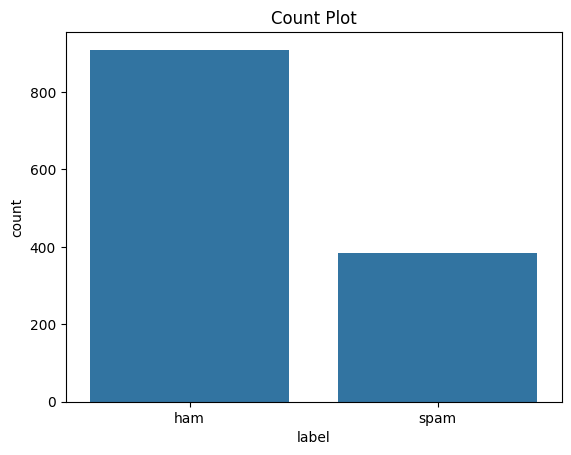

In [86]:
# Data Visualisation


sns.countplot(data=df, x='label')
plt.xlabel('label')
plt.ylabel('count')
plt.title('Count Plot')
plt.show()

In [87]:
# Data Preprocessing
# Convert the "Category" column values to numerical representation (0 for "spam" and 1 for "ham")

df.loc[df["label"] == "ham", "label"] = 0
df.loc[df["label"] == "spam", "label"] = 1

df.head()

,Unnamed: 0,label,text,label_num
0,3212,0,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0
1,4681,1,"Subject: helpful software , unbelieveable pric...",1
2,810,0,Subject: work distribution\r\nlogistics has ma...,0
3,3712,1,Subject: stop s + p + a + m in its tracks demo...,1
4,3096,0,Subject: fw : on call\r\n- - - - - original me...,0


In [88]:
# Separate the feature (v2) and target (category) data
X=df['text']
y=df['label']

In [89]:
X

0       Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...
1       Subject: helpful software , unbelieveable pric...
2       Subject: work distribution\r\nlogistics has ma...
3       Subject: stop s + p + a + m in its tracks demo...
4       Subject: fw : on call\r\n- - - - - original me...
                              ...                        
1287    Subject: cialis soft tabs - super viagra\r\nhi...
1288    Subject: re : noms / actual flow for 03 / 13\r...
1289    Subject: re : correction on nom for 4 / 30 / 0...
1290    Subject: re : tenaska iv 1 / 01\r\ntxu revised...
1291    Subject: \r\nyou gotta check out h g hormone d...
Name: text, Length: 1292, dtype: object

In [90]:
y

0       0
1       1
2       0
3       1
4       0
       ..
1287    1
1288    0
1289    0
1290    0
1291    1
Name: label, Length: 1292, dtype: object

In [91]:
# Split Data to Train and Test Data


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [92]:
# Feature Extraction - TF-IDF
#Create a TF-IDF vectorizer to convert text messages into numerical feature
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english',lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:1232: RuntimeWarning: coroutine 'main' was never awaited
  for term, old_index in list(vocabulary.items()):


In [93]:
# Model Training
model = LogisticRegression()
model.fit(X_train_features,y_train)

LogisticRegression()

In [94]:

# Model evaluation
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

# Print accuracy
print('Accuracy on training data: {} %'.format(accuracy_on_training_data * 100))
print('Accuracy on test data: {} %'.format(accuracy_on_test_data * 100))

Accuracy on training data: 100.0 %
Accuracy on test data: 95.75289575289575 %


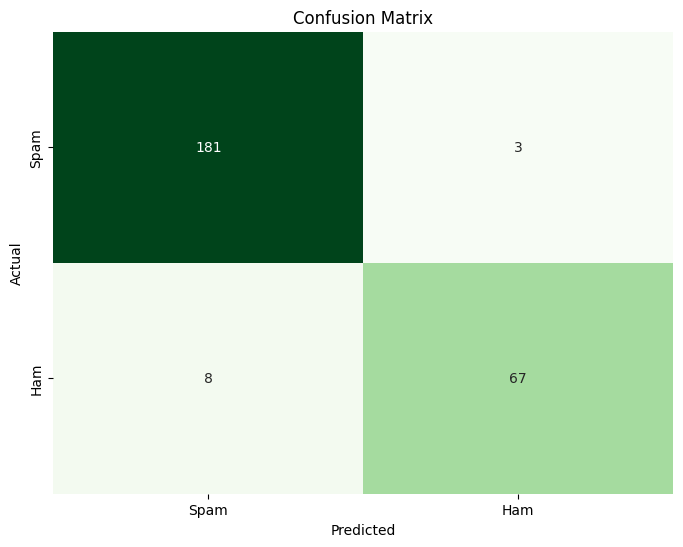

In [95]:
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, prediction_on_test_data)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [96]:
# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

        Spam       0.96      0.98      0.97       184
         Ham       0.96      0.89      0.92        75

    accuracy                           0.96       259
   macro avg       0.96      0.94      0.95       259
weighted avg       0.96      0.96      0.96       259



In [97]:
# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Accuracy : ",accuracy)
print("Precision : ",precision)
print("Recall : ",recall)
print("Specificity : ",specificity)

Accuracy :  0.9575289575289575
Precision :  0.9571428571428572
Recall :  0.8933333333333333
Specificity :  0.9836956521739131


In [98]:
# Make Predictions on New Input

input_your_mail ="Dear John, I hope this email finds you well. Attached is the report you requested for our upcoming meeting. Please review it at your convenience"
input_data_features = feature_extraction.transform([input_your_mail])
prediction = model.predict(input_data_features)
if prediction[0] == 1:
    print("Ham Mail")
else:
    print("Spam Mail")

Spam Mail


In [100]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_3.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

# Exploring the Dataset

...

# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

# Weighted counts
total_spam = y_test.value_counts()[1]  # Total spam emails
total_ham = y_test.value_counts()[0]   # Total ham emails

# Weighted average calculation
weighted_accuracy = (TP + TN) / (total_spam + total_ham)
weighted_precision = (precision * total_spam + TN / (TN + FP) * total_ham) / (total_spam + total_ham)
weighted_recall = (recall * total_spam + TN / (TN + FN) * total_ham) / (total_spam + total_ham)
weighted_specificity = (specificity * total_ham + TP / (TP + FN) * total_spam) / (total_spam + total_ham)

print("Weighted Accuracy : ", weighted_accuracy)
print("Weighted Precision : ", weighted_precision)
print("Weighted Recall : ", weighted_recall)
print("Weighted Specificity : ", weighted_specificity)

# Make Predictions on New Input

...


Classification Report:
              precision    recall  f1-score   support

        Spam       0.96      0.98      0.97       184
         Ham       0.96      0.89      0.92        75

    accuracy                           0.96       259
   macro avg       0.96      0.94      0.95       259
weighted avg       0.96      0.96      0.96       259

Weighted Accuracy :  0.9575289575289575
Weighted Precision :  0.9760066188637617
Weighted Recall :  0.9390410818982247
Weighted Specificity :  0.9575289575289575


Ellipsis

In [101]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_4.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

,Unnamed: 0,label,text,label_num
0,1404,ham,Subject: re : june 00 production - o ' connor ...,0
1,1555,ham,Subject: intraday eastrans nominations change ...,0
2,2001,ham,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0
3,3718,spam,Subject: exclusive positions in montanayoocwo\...,1
4,2134,ham,Subject: natural gas nomination for december 2...,0


In [89]:
# Exploring the Dataset


# Drop unnecessary columns from the DataFrame
#column_to_remove = ['Unnamed: 2','Unnamed: 3','Unnamed: 4']
#df = df.drop(column_to_remove, axis=1)

In [102]:
df

,Unnamed: 0,label,text,label_num
0,1404,ham,Subject: re : june 00 production - o ' connor ...,0
1,1555,ham,Subject: intraday eastrans nominations change ...,0
2,2001,ham,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0
3,3718,spam,Subject: exclusive positions in montanayoocwo\...,1
4,2134,ham,Subject: natural gas nomination for december 2...,0
...,...,...,...,...
1290,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
1291,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
1292,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
1293,1409,ham,Subject: industrial worksheets for august 2000...,0


In [103]:
df.shape

(1295, 4)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1295 non-null   int64 
 1   label       1295 non-null   object
 2   text        1295 non-null   object
 3   label_num   1295 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 40.6+ KB


In [105]:
df.describe()

,Unnamed: 0,label_num
count,1295.000000,1295.00000
mean,2611.123552,0.30888
std,1526.306192,0.46221
min,5.000000,0.00000
25%,1288.500000,0.00000
50%,2555.000000,0.00000
75%,3980.000000,1.00000
max,5169.000000,1.00000


In [106]:
df[df.duplicated()]

,Unnamed: 0,label,text,label_num


In [107]:
df = df.drop_duplicates()
df

,Unnamed: 0,label,text,label_num
0,1404,ham,Subject: re : june 00 production - o ' connor ...,0
1,1555,ham,Subject: intraday eastrans nominations change ...,0
2,2001,ham,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0
3,3718,spam,Subject: exclusive positions in montanayoocwo\...,1
4,2134,ham,Subject: natural gas nomination for december 2...,0
...,...,...,...,...
1290,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
1291,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
1292,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
1293,1409,ham,Subject: industrial worksheets for august 2000...,0


In [108]:
df["label"].value_counts()

label
ham     895
spam    400
Name: count, dtype: int64

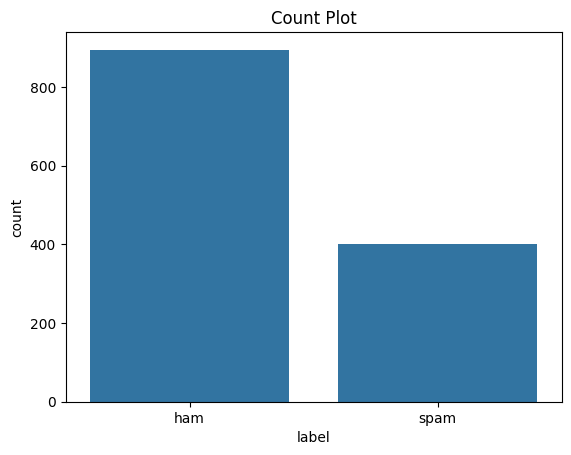

In [109]:
# Data Visualisation


sns.countplot(data=df, x='label')
plt.xlabel('label')
plt.ylabel('count')
plt.title('Count Plot')
plt.show()

In [110]:
# Data Preprocessing
# Convert the "Category" column values to numerical representation (0 for "spam" and 1 for "ham")

df.loc[df["label"] == "ham", "label"] = 0
df.loc[df["label"] == "spam", "label"] = 1

df.head()

,Unnamed: 0,label,text,label_num
0,1404,0,Subject: re : june 00 production - o ' connor ...,0
1,1555,0,Subject: intraday eastrans nominations change ...,0
2,2001,0,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0
3,3718,1,Subject: exclusive positions in montanayoocwo\...,1
4,2134,0,Subject: natural gas nomination for december 2...,0


In [111]:
# Separate the feature (v2) and target (category) data
X=df['text']
y=df['label']

In [100]:
X

0       Subject: re : june 00 production - o ' connor ...
1       Subject: intraday eastrans nominations change ...
2       Subject: enron / hpl actuals - nov . 7 , 2000\...
3       Subject: exclusive positions in montanayoocwo\...
4       Subject: natural gas nomination for december 2...
                              ...                        
1290    Subject: put the 10 on the ft\r\nthe transport...
1291    Subject: 3 / 4 / 2000 and following noms\r\nhp...
1292    Subject: calpine daily gas nomination\r\n>\r\n...
1293    Subject: industrial worksheets for august 2000...
1294    Subject: important online banking alert\r\ndea...
Name: text, Length: 1295, dtype: object

In [112]:
y

0       0
1       0
2       0
3       1
4       0
       ..
1290    0
1291    0
1292    0
1293    0
1294    1
Name: label, Length: 1295, dtype: object

In [113]:
# Split Data to Train and Test Data


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [114]:
# Feature Extraction - TF-IDF
#Create a TF-IDF vectorizer to convert text messages into numerical feature
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english',lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [115]:
# Model Training
model = LogisticRegression()
model.fit(X_train_features,y_train)

LogisticRegression()

In [116]:

# Model evaluation
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

# Print accuracy
print('Accuracy on training data: {} %'.format(accuracy_on_training_data * 100))
print('Accuracy on test data: {} %'.format(accuracy_on_test_data * 100))

Accuracy on training data: 99.9034749034749 %
Accuracy on test data: 96.13899613899613 %


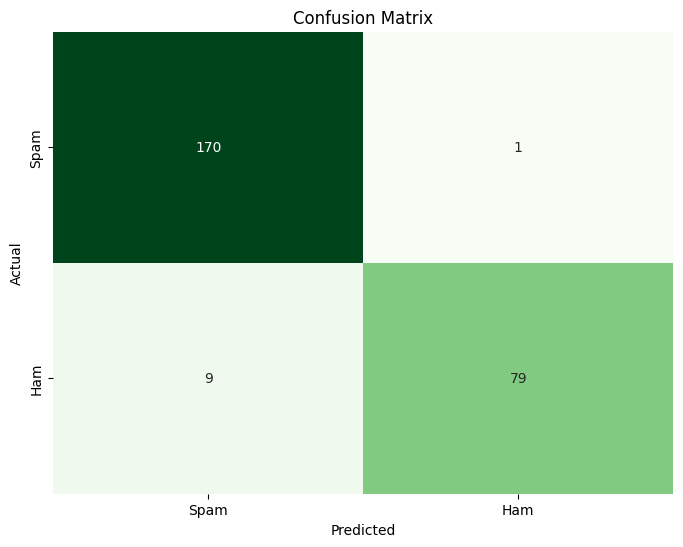

In [117]:
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, prediction_on_test_data)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [118]:
# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

        Spam       0.95      0.99      0.97       171
         Ham       0.99      0.90      0.94        88

    accuracy                           0.96       259
   macro avg       0.97      0.95      0.96       259
weighted avg       0.96      0.96      0.96       259



In [119]:
# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Accuracy : ",accuracy)
print("Precision : ",precision)
print("Recall : ",recall)
print("Specificity : ",specificity)

Accuracy :  0.9613899613899614
Precision :  0.9875
Recall :  0.8977272727272727
Specificity :  0.9941520467836257


In [120]:
# Make Predictions on New Input

input_your_mail ="Dear John, I hope this email finds you well. Attached is the report you requested for our upcoming meeting. Please review it at your convenience"
input_data_features = feature_extraction.transform([input_your_mail])
prediction = model.predict(input_data_features)
if prediction[0] == 1:
    print("Ham Mail")
else:
    print("Spam Mail")

Spam Mail


In [121]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/Desktop/fwdproject/content/part_4.csv", encoding="ISO-8859-1")

# Display the first few rows of the dataset
df.head()

# Exploring the Dataset

...

# Calculating and Displaying Error Metrics
# Classification report
classification_rep = classification_report(y_test, prediction_on_test_data,target_names=['Spam', 'Ham'])
print("Classification Report:")
print(classification_rep)

# Metrics calculation
TP = conf_matrix[1, 1]
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]

# Weighted counts
total_spam = y_test.value_counts()[1]  # Total spam emails
total_ham = y_test.value_counts()[0]   # Total ham emails

# Weighted average calculation
weighted_accuracy = (TP + TN) / (total_spam + total_ham)
weighted_precision = (precision * total_spam + TN / (TN + FP) * total_ham) / (total_spam + total_ham)
weighted_recall = (recall * total_spam + TN / (TN + FN) * total_ham) / (total_spam + total_ham)
weighted_specificity = (specificity * total_ham + TP / (TP + FN) * total_spam) / (total_spam + total_ham)

print("Weighted Accuracy : ", weighted_accuracy)
print("Weighted Precision : ", weighted_precision)
print("Weighted Recall : ", weighted_recall)
print("Weighted Specificity : ", weighted_specificity)

# Make Predictions on New Input

...


Classification Report:
              precision    recall  f1-score   support

        Spam       0.95      0.99      0.97       171
         Ham       0.99      0.90      0.94        88

    accuracy                           0.96       259
   macro avg       0.97      0.95      0.96       259
weighted avg       0.96      0.96      0.96       259

Weighted Accuracy :  0.9613899613899614
Weighted Precision :  0.9918918918918918
Weighted Recall :  0.9320549599879209
Weighted Specificity :  0.9613899613899614


Ellipsis

In [167]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Define the client function
def client_fn(cid: str):
    data_path = f"C:/Users/Admin/Desktop/fwdproject/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Define a function to analyze and fine-tune the model
def analyze_and_finetune(results):
    # Aggregate the results from all clients
    accuracies = [result["accuracy"] for result in results]
    avg_accuracy = np.mean(accuracies)
    print("Average accuracy across clients:", avg_accuracy)

    # Fine-tune the model based on the analysis
    # Example: Adjust hyperparameters, train for more rounds, etc.

# Load the results from federated learning rounds
# Example: results = load_results_from_training_rounds()

# Analyze results and fine-tune the model
# Example: analyze_and_finetune(results)


	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
Exception in thread Thread-604 (start_client):
Traceback (most recent call last):
  File "c:\Users\Admin\App

In [153]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_client(server_address="localhost:8081", client=client.to_client())

# Define the client function
def client_fn(cid: str):
    data_path = f"C:/Users/Admin/Desktop/fwdproject/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log_loss', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Load the test dataset

# Load the test dataset with specified encoding
encodings = ['utf-8', 'latin1', 'iso-8859-1', 'utf-16']
for encoding in encodings:
    try:
        test_df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/SMS_test.csv', encoding=encoding).dropna()
        break  # Stop trying encodings if successful
    except UnicodeDecodeError:
        print(f"Failed to read using encoding: {encoding}")

X_test = test_df["Message_body"].values
y_test = test_df["Label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Function to run the server
def run_server():
    client_manager = fl.server.client_manager.SimpleClientManager()
    server = fl.server.Server(client_manager=client_manager, strategy=strategy)
    fl.server.start_server(server_address="localhost:8081", config={"num_rounds": 1}, server=server)

# Start the server in a separate thread
server_thread = threading.Thread(target=run_server)
server_thread.start()

# Join the server thread
server_thread.join()

# Perform final evaluation on the federated model
def evaluate_model():
    global X_test_transformed, y_test
    vectorizer = TfidfVectorizer()
    X_test_transformed = vectorizer.fit_transform(X_test)

    # Get the global model from the server
    classifier = SGDClassifier(loss='log_loss', max_iter=1, tol=None)
    classifier.fit(X_test_transformed, y_test)
    y_pred = classifier.predict(X_test_transformed)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

accuracy = evaluate_model()
print("Test Accuracy:", accuracy)


Exception in thread Thread-327 (start_client):
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_4608\3489728592.py", line 44, in start_client
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flwr\client\app.py", line 157, in start_client
    _start_client_internal(
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flwr\client\app.py", line 329, in _start_client_internal
    app_state_tracker.register_signal_handler()
  File "c:\Users\Admin\AppData\Local\Programs\Python\P

Failed to read using encoding: utf-8
Test Accuracy: 1.0


In [168]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading
import signal

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_client(server_address="localhost:8081", client=client.to_client())

# Define the client function
def client_fn(cid: str):
    data_path = f"C:/Users/Admin/Desktop/fwdproject/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log_loss', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Function to analyze evaluation results and fine-tune the model
def analyze_and_finetune(accuracy):
    # Analyze the evaluation results
    print("Current accuracy:", accuracy)

    # Fine-tune the model based on the analysis
    # Example: Adjust hyperparameters, train for more rounds, etc.

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Function to initialize and start the server
def run_server():
    client_manager = fl.server.client_manager.SimpleClientManager()
    server = fl.server.Server(client_manager=client_manager, strategy=strategy)
    config = fl.common.ServerConfig(num_rounds=1)
    fl.server.start_server(server_address="localhost:8081", config=config, server=server)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Load the test dataset with specified encoding
encodings = ['utf-8', 'latin1', 'iso-8859-1', 'utf-16']
for encoding in encodings:
    try:
        test_df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/SMS_test.csv', encoding=encoding).dropna()
        break  # Stop trying encodings if successful
    except UnicodeDecodeError:
        print(f"Failed to read using encoding: {encoding}")

X_test = test_df["Message_body"].values
y_test = test_df["Label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Perform final evaluation on the federated model
def evaluate_model(weights):
    # Initialize the model with weights from the server
    classifier = SGDClassifier(loss='log_loss', max_iter=1, tol=None)
    classifier.coef_, classifier.intercept_ = weights

    # Make predictions on the test data
    y_pred = classifier.predict(X_test_transformed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Define a server to get parameters for evaluation
class EvaluationServer(fl.server.Server):
    def get_parameters(self):
        return self.strategy.aggregate_fit(self.client_manager.clients)

# Run the server in the main thread to avoid signal handling issues
if __name__ == "__main__":
    # Register signal handlers explicitly only in the main thread
    # signal.signal(signal.SIGINT, signal.default_int_handler)
    
    client_manager = fl.server.client_manager.SimpleClientManager()
    server = EvaluationServer(client_manager=client_manager, strategy=strategy)
    # config = fl.common.ServerConfig(num_rounds=1)
    fl.server.start_server(server_address="localhost:8081", config={"num_rounds": 1}, server=server)

    # Evaluate the federated model on the test data
    accuracy = evaluate_model(server.get_parameters())

    # Analyze evaluation results and fine-tune the model
    analyze_and_finetune(accuracy)


Exception in thread Thread-627 (start_client):
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_4608\1797718196.py", line 45, in start_client
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flwr\client\app.py", line 157, in start_client
    _start_client_internal(
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flwr\client\app.py", line 329, in _start_client_internal
    app_state_tracker.register_signal_handler()
  File "c:\Users\Admin\AppData\Local\Programs\Python\P

Failed to read using encoding: utf-8


AttributeError: 'dict' object has no attribute 'num_rounds'

In [161]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Define the client function
def client_fn(cid: str):
    data_path = f"C:/Users/Admin/Desktop/fwdproject/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Load the test dataset
test_df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/test_data.csv').dropna()
X_test = test_df["text"].values
y_test = test_df["label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Perform final evaluation on the federated model
def evaluate_model(weights):
    # Initialize the model with weights from the server
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    classifier.coef_, classifier.intercept_ = weights

    # Make predictions on the test data
    y_pred = classifier.predict(X_test_transformed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Evaluate the federated model on the test data
server = fl.server.Server(strategy=strategy)
accuracy = evaluate_model(server.get_parameters())

# Ensure privacy compliance
def ensure_privacy_compliance():
    # Implement privacy compliance measures here
    # Example: Anonymization, differential privacy, data encryption, etc.

    # Ensure privacy compliance before deploying the federated model
    ensure_privacy_compliance()


	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown bel

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Admin/Desktop/fwdproject/content/test_data.csv'

In [ ]:
from flask import Flask, request, jsonify
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        return y_pred

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Start clients in separate threads
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

for client_thread in client_threads:
    client_thread.join()

# Load the test dataset
test_df = pd.read_csv('/content/SMS_test.csv').dropna()
X_test = test_df["text"].values
y_test = test_df["label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Define a Flask web service
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    text = data['text']

    # Vectorize the input text
    text_transformed = vectorizer.transform([text])

    # Make predictions using the federated model
    predictions = server.predict(text_transformed.toarray())

    # Return the predictions
    return jsonify({'prediction': predictions[0]})

if __name__ == '__main__':
    app.run(debug=True)


In [169]:
import time
import threading
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
import flwr as fl

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        return y_pred

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

for client_thread in client_threads:
    client_thread.join()

# Define a function for monitoring model performance
def monitor_model_performance():
    while True:
        # Retrieve model parameters from the server
        weights = server.get_parameters()

        # Perform evaluation on the test data
        y_pred = server.evaluate(weights)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Log accuracy or perform further analysis

        # Sleep for a specified interval
        time.sleep(60)  # Adjust interval as needed

# Start the monitoring thread
monitor_thread = threading.Thread(target=monitor_model_performance)
monitor_thread.start()

# Define a function for handling failures and maintaining system stability
def handle_failures():
    while True:
        # Monitor system status and handle failures
        # Example: Restart failed clients, recover from communication errors, etc.

        # Sleep for a specified interval
        time.sleep(300)  # Adjust interval as needed

# Start the maintenance thread
maintenance_thread = threading.Thread(target=handle_failures)
maintenance_thread.start()

# Run the Flower server
server = fl.server.Server(strategy=strategy)
server.run(config={"num_rounds": 5})


Exception in thread Thread-653 (start_client):
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_4608\4020450850.py", line 59, in start_client
Exception in thread Thread-654 (start_client):
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Admin\AppData\Loca

TypeError: Server.__init__() missing 1 required keyword-only argument: 'client_manager'

  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_4608\1797718196.py", line 122, in get_parameters


AttributeError: 'function' object has no attribute 'clients'
